# Exercices : à vous de jouer !


## Exercice 1 : approximation d'une intégrale par méthode de Monte-Carlo.
1. Calculez $I=\int_0^1 \frac{p^2}{4} dp$.
2. Remplissez un tableau `A` de 10000 couples $(p,q)$ issus d'une loi uniforme sur l'intervalle $[0,1]$.
3. Calculez la proportion $\tilde{I}$ des couples $(p,q)$ qui vérifient $q < \frac{p^2}{4}$ (on créera un tableau 1D de taille 10000 contenant 0 ou 1 selon que la condition est vérifiée ou pas, puis sommer tous les termes de ce tableau).
4. Sur une fenêtre graphique, représentez EN ROUGE les points situés en dessous de la courbe $q=\frac{p^2}{4}$ et en VERT les autres.
5. Concluez.


## Exercice 1 - vos réponses...

$I=\int_0^1 \frac{p^2}{4} dp$ = [1/12] - [0] = 1/12 = 0,08333..

0.08241


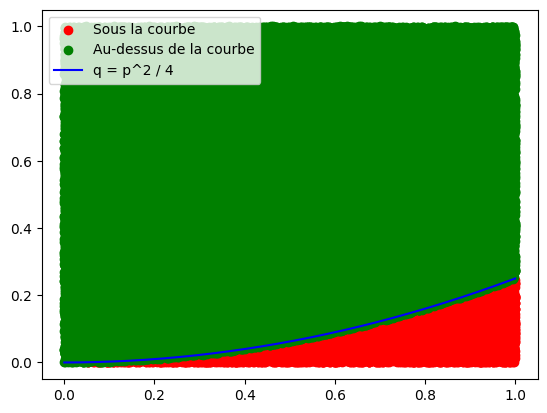

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import math

approx = 100000

A = np.zeros([approx,2])

for i in range (approx):
    A[i][0] = np.random.rand()
    A[i][1] = np.random.rand()

I = np.zeros([approx])
for i in range (approx):
    if A[i][1] < A[i][0]**2/4:
        I[i] = 1
    else:
        I[i] = 0

somme = 0
for i in range (approx):
    somme = somme + I[i]

print(somme/approx)

fig, ax = plt.subplots()
ax.scatter( A[I==1, 0], A[I==1, 1], color = 'red', label = 'Sous la courbe')
ax.scatter( A[I==0, 0], A[I==0, 1], color = 'green', label = 'Au-dessus de la courbe')

p_values = np.linspace(0,1,10000)
q_values = p_values**2 / 4
ax.plot(p_values, q_values, color='blue', label='q = p^2 / 4')

ax.legend()
plt.show()

Conclusion: Avec cette méthode, nous avons approximé l'intégrale en calculant la proportion de points sous la courbe.
Cette proportion nous a donné une approximation proche de la valeur exacte de l'intégrale que nous avion calculé précédemment



## Exercice 2
On s'intéresse aux solutions de l'équation $x^2+px+q=0$. Supposons que $(p,q)$ sont des nombres aléatoires issus d'une loi uniforme sur $[0,1]$ (comme précédemment).
1. Intuitivement, quelle est la loi de probabilité suivie par le nombre de solutions d'une équation du second degré. Autrement dit, si $X$ désigne la variable aléatoire égale au nombre de solution de l'équation $x^2+px+q=0$, que valent les probabilités $P(X=0)$, $P(X=1)$ et $P(X=2)$.
2. Voyez-vous un lien avec l'exercice précédent ?
3. Ecrivez une fonction `binome(p,q)` qui permet de calculer le nombre de solutions distinctes de l'équation $x^2+px+q = 0$. 
4. Pour chaque couple du tableau `A` (de l'exercice précédent), stockez le nombre de solutions dans un tableau `S`.
5. Calculez les proportions de triplets qui conduisent à 0, 1 ou 2 solutions (on pourra par exemple utiliser `(S==1).sum()` pour calculer le nombre de couples correspondants à 1 solution). Cela confirme-t-il votre intuition ?


## Exercice 2 - vos réponses...

- Les valeurs de p et q influencent directement le discriminant.
- Puisque p et q suivent une loi uniforme sur [0,1], les cas où Δ est positif, nul ou négatif dépendent de la relation géométrique entre p^2 et 4q.
- P(X=0) sera le plus élevé, car q<p^2/4 représente la majeure partie des couples.
- P(X=1) sera faible, car le cas où q=p^2/4 est une ligne dans l’espace des couples.
- P(X=2) sera modéré, car q>p2/4 représente une partie complémentaire.
Probabilite de P(X=0) sera plus eleve que de P(X=2) car la fonction est faiblement croissante.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math

def binome(p, q):
    delta = p**2 - 4*q
    if delta < 0:
        return 0
    elif delta == 0:
        return 1
    else:
        return 2

approx = 100000

A = np.zeros([approx,2])
for i in range (approx):
    A[i][0] = np.random.rand()
    A[i][1] = np.random.rand()


S = np.zeros([approx])
for i in range (approx):
    S[i] = binome(A[i][0], A[i][1])

s0 = (S==0).sum()
s1 = (S==1).sum()  
s2 = (S==2).sum()  

print(s0, s1, s2)

91720 0 8280


## Exercice 3
Dans cet exercice, on étudie l'influence du type des éléments d'un tableau sur le résultats de certaines opérations élémentaires.
1. Créez deux tableaux `numpy` 1d, `l1` et `l2`, contenant les 10 premiers entiers 0, 1, 2,..., 9 (utilisez la commande `np.arange()`).
2. Convertissez `l1` en type `np.uint8`(8-bit) et `l2` en type `np.float32` (utilisez `l1.astype()`...).
3. 
    - Cas 1. Multipliez chacune des deux listes par 30.: `l1_bis = l1*30.` et `l2_bis = l2 * 30.` (respectez scrupuleusement les instructions précédentes). Le résultat est-il conforme à ce que vous attendiez ? Quel est le type des éléments de `l1_bis` ? 
    - Cas 2 : Multipliez chacune des deux listes par 30: `l1_ter = l1*30` et `l2_ter = l2 * 30` (notez la différence). Que se passe-t-il ? Le résultat obtenu pour `l1` est-il conforme à ce que vous attendiez ?
4. Faites plusieurs tests (avec un tableau d'une seule valeur) pour comprendre ce qu'il se passe. Commentez.

Remarque : cet exercice sera important pour les TP suivants. La plupart des images que vous manipulerez seront codées sur 8-bits, mais les opérations que vous serez amenés à faire sur ces images pourront entrainer des comportements inattendus. Cet exercice vous permettra de mieux comprendre ce qu'il se passe.


## Exercice 3 - vos réponses...

Conclusion: Les types entiers (comme uint8) sont efficaces en termes de mémoire mais peuvent poser des problèmes d’overflow.
Les types flottants (comme float32) offrent une plus grande flexibilité pour les calculs mais occupent plus de mémoire et peuvent introduire des approximations.

In [11]:
import numpy as np
l1 = np.arange(10)
l2 = np.arange(10)

print(l1)
print(l2)

l1 = l1.astype(np.uint8)
l2 = l2.astype(np.float32)

print(l1)
print(l2)

l1_bis = l1 * 30.
l2_bis = l2 * 30.

print(l1_bis)
print(l2_bis)

l1_ter = l1 * 30
l2_ter = l2 * 30

print(l1_ter)
print(l2_ter)

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[  0.  30.  60.  90. 120. 150. 180. 210. 240. 270.]
[  0.  30.  60.  90. 120. 150. 180. 210. 240. 270.]
[  0  30  60  90 120 150 180 210 240  14]
[  0.  30.  60.  90. 120. 150. 180. 210. 240. 270.]
